#Date : March 18, 2026

#Project : Customer Churn Prediction System using the Support Vector Machine (SVM) algorithm.

# Assigned to : Ritika Deshmukh, Data Analyst, MacroEdtech


#Objective :
 The objective of this project is to develop a machine learning-based Customer Churn Prediction System using the Support Vector Machine (SVM) algorithm. The goal is to identify customers who are likely to discontinue a service based on their behavioral and account-related features. By applying data preprocessing, exploratory data analysis (EDA), and supervised learning techniques, the model aims to learn patterns that distinguish between churn and non-churn customers. This system can help businesses make data-driven decisions, improve customer retention strategies, and reduce revenue loss by proactively identifying high-risk customers.

#Dataset

The dataset used in this project is a synthetically generated but structured Customer Churn dataset consisting of 10,000 records. Each record represents a customer with features such as tenure, monthly charges, total charges, contract type, internet service type, technical support, online security, payment method, and billing preferences. The target variable, “churn”, indicates whether a customer has left the service (1) or not (0). The dataset is designed with meaningful relationships between features (e.g., customers with low tenure and high monthly charges are more likely to churn), making it suitable for training machine learning models like SVM and achieving realistic performance.

# Import Libraries

In [ ]:
#Data Handling
import pandas as pd
import numpy as np

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Data Preprocessing
from sklearn.preprocessing import StandardScaler

#Model Selection
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

#Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Explaination : We used pandas and numpy for data handling, seaborn and matplotlib is used for visulaization, StandardScaler is used for preprocessing, SVM for modeling and sklearn tools for evaluation and optimization.

# Upload data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_svm_ml_dataset.csv to customer_churn_svm_ml_dataset.csv


Explaination: we have successfully uploaded customer_churn_svm_ml_dataset.csv data file from our local machine to google colab.

# Load data

In [ ]:
df = pd.read_csv('customer_churn_svm_ml_dataset.csv')
df.head(10)

,customer_id,tenure,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,payment_method,paperless_billing,churn
0,1,52,36.16,2681.58,2,0,1,0,1,1,0
1,2,15,31.84,684.19,2,1,1,0,3,1,0
2,3,61,96.07,7098.61,1,2,0,1,2,1,0
3,4,21,112.75,1478.63,0,2,1,1,2,0,1
4,5,24,65.83,5077.39,2,0,0,0,2,1,1
5,6,3,85.94,5187.34,2,1,1,1,3,0,1
6,7,22,111.45,2321.10,1,2,1,1,1,0,0
7,8,53,29.01,7886.72,2,2,1,0,2,0,0
8,9,2,97.05,606.91,2,0,0,0,2,1,1
9,10,30,81.68,4902.19,2,2,0,0,0,1,0


Explaination : Reads the csv file into a pandas dataframe using read_csv() and head(10) function displays the first 10 rows to quickly inspect the data structure, coluum names and sample values.

# Data Understand

In [ ]:
df.info() #shows datatypes and missing value if any

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        10000 non-null  int64  
 1   tenure             10000 non-null  int64  
 2   monthly_charges    10000 non-null  float64
 3   total_charges      10000 non-null  float64
 4   contract_type      10000 non-null  int64  
 5   internet_service   10000 non-null  int64  
 6   tech_support       10000 non-null  int64  
 7   online_security    10000 non-null  int64  
 8   payment_method     10000 non-null  int64  
 9   paperless_billing  10000 non-null  int64  
 10  churn              10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


In [ ]:
df.describe() #statistics

,customer_id,tenure,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,payment_method,paperless_billing,churn
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,35.997600,69.770442,4084.477606,1.010400,0.997500,0.501700,0.501100,1.509500,0.501800,0.368400
std,2886.89568,20.457313,28.698753,2286.229267,0.809171,0.818389,0.500022,0.500024,1.120462,0.500022,0.482395
min,1.00000,1.000000,20.000000,100.160000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2500.75000,18.000000,45.230000,2115.450000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,5000.50000,36.000000,69.675000,4096.385000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000
75%,7500.25000,54.000000,94.190000,6069.790000,2.000000,2.000000,1.000000,1.000000,3.000000,1.000000,1.000000
max,10000.00000,71.000000,119.990000,7999.790000,2.000000,2.000000,1.000000,1.000000,3.000000,1.000000,1.000000


In [ ]:
df.isna().sum() #check missing value

,0
customer_id,0
tenure,0
monthly_charges,0
total_charges,0
contract_type,0
internet_service,0
tech_support,0
online_security,0
payment_method,0
paperless_billing,0


# Data Preprocessing

Seperate Features and Target

In [ ]:
X = df.drop('churn', axis=1)
y = df['churn']

Explaination: Here, the dataset is seperated into features (X) and target variable (y). X contains all input varibales and y contain the 'churn' column that we aim to predict.

Feature scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Explaination: Standardizes the feature set using StandardScaler. fit_transform() calculates mean and std and scales all features to ensure equal importance for the SVM model.

# EDA

Churn Distribution

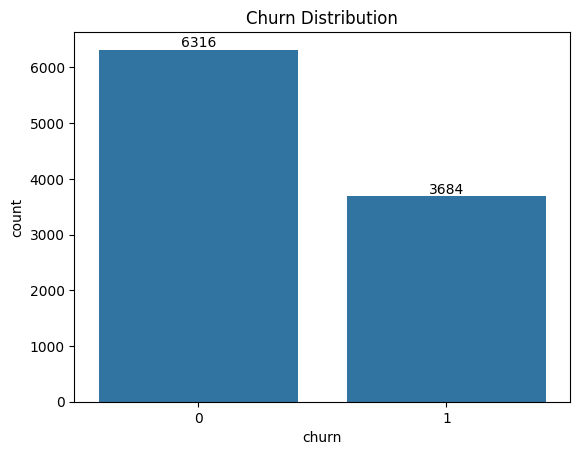

In [ ]:
ax = sns.countplot(x='churn', data=df)
ax.bar_label(ax.containers[0])
plt.title('Churn Distribution')
plt.show()

Explaination: Visulaizes the distribution of the target variable 'churn' using a countplot.

Feature distribution

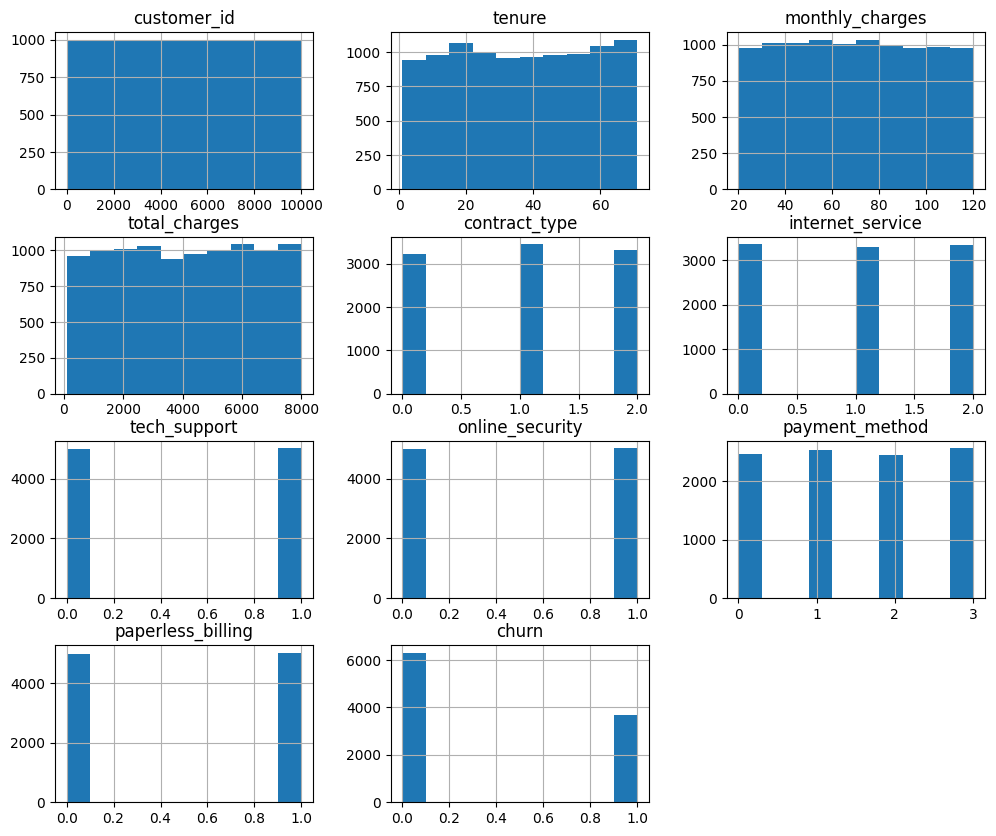

In [ ]:
df.hist(figsize=(12,10))
plt.show()

Explaination : Displays the distribution of all numerical features, helping to understand data spread and potential outliners.

Correlation heatmap

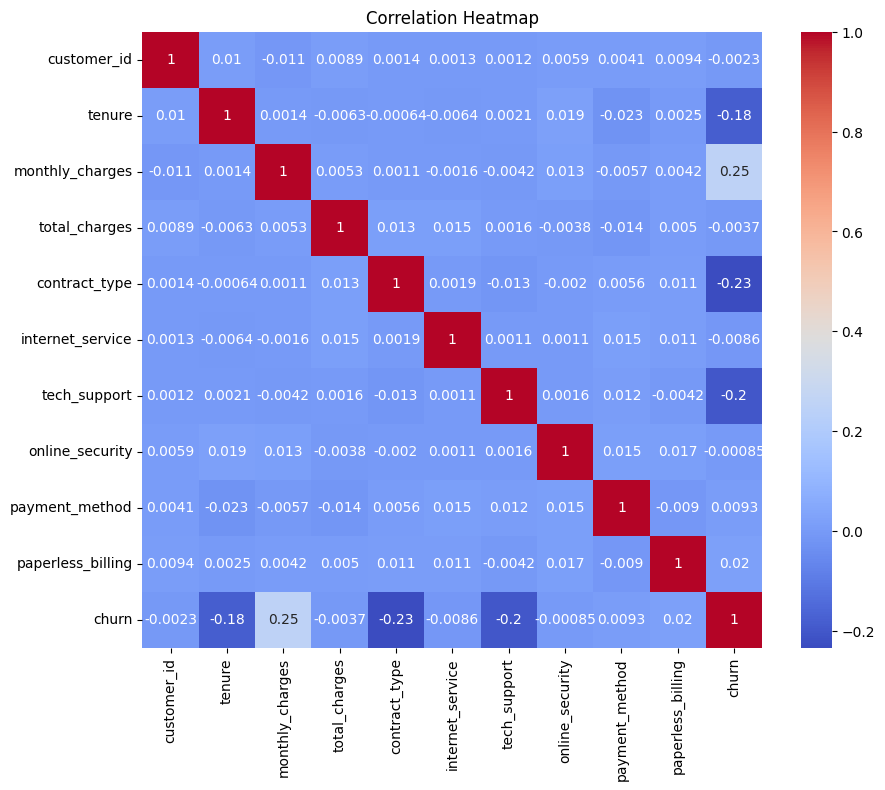

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap= 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Explaination: shows the correlation between features, helping identify string relationships and important variables influencing churn.

Boxplot (churn vs charges)

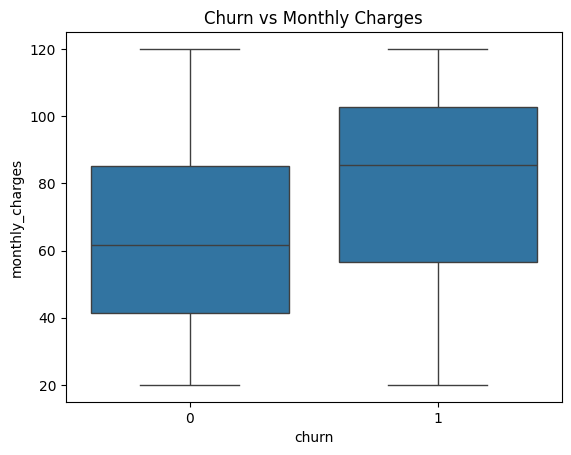

In [ ]:
sns.boxplot(x='churn', y='monthly_charges', data=df)
plt.title('Churn vs Monthly Charges')
plt.show()

Explaination: compares monthly charges across churn and non-churn customers, helping detect patterns and outliners affecting churn behavior.

Relationship between multiple features

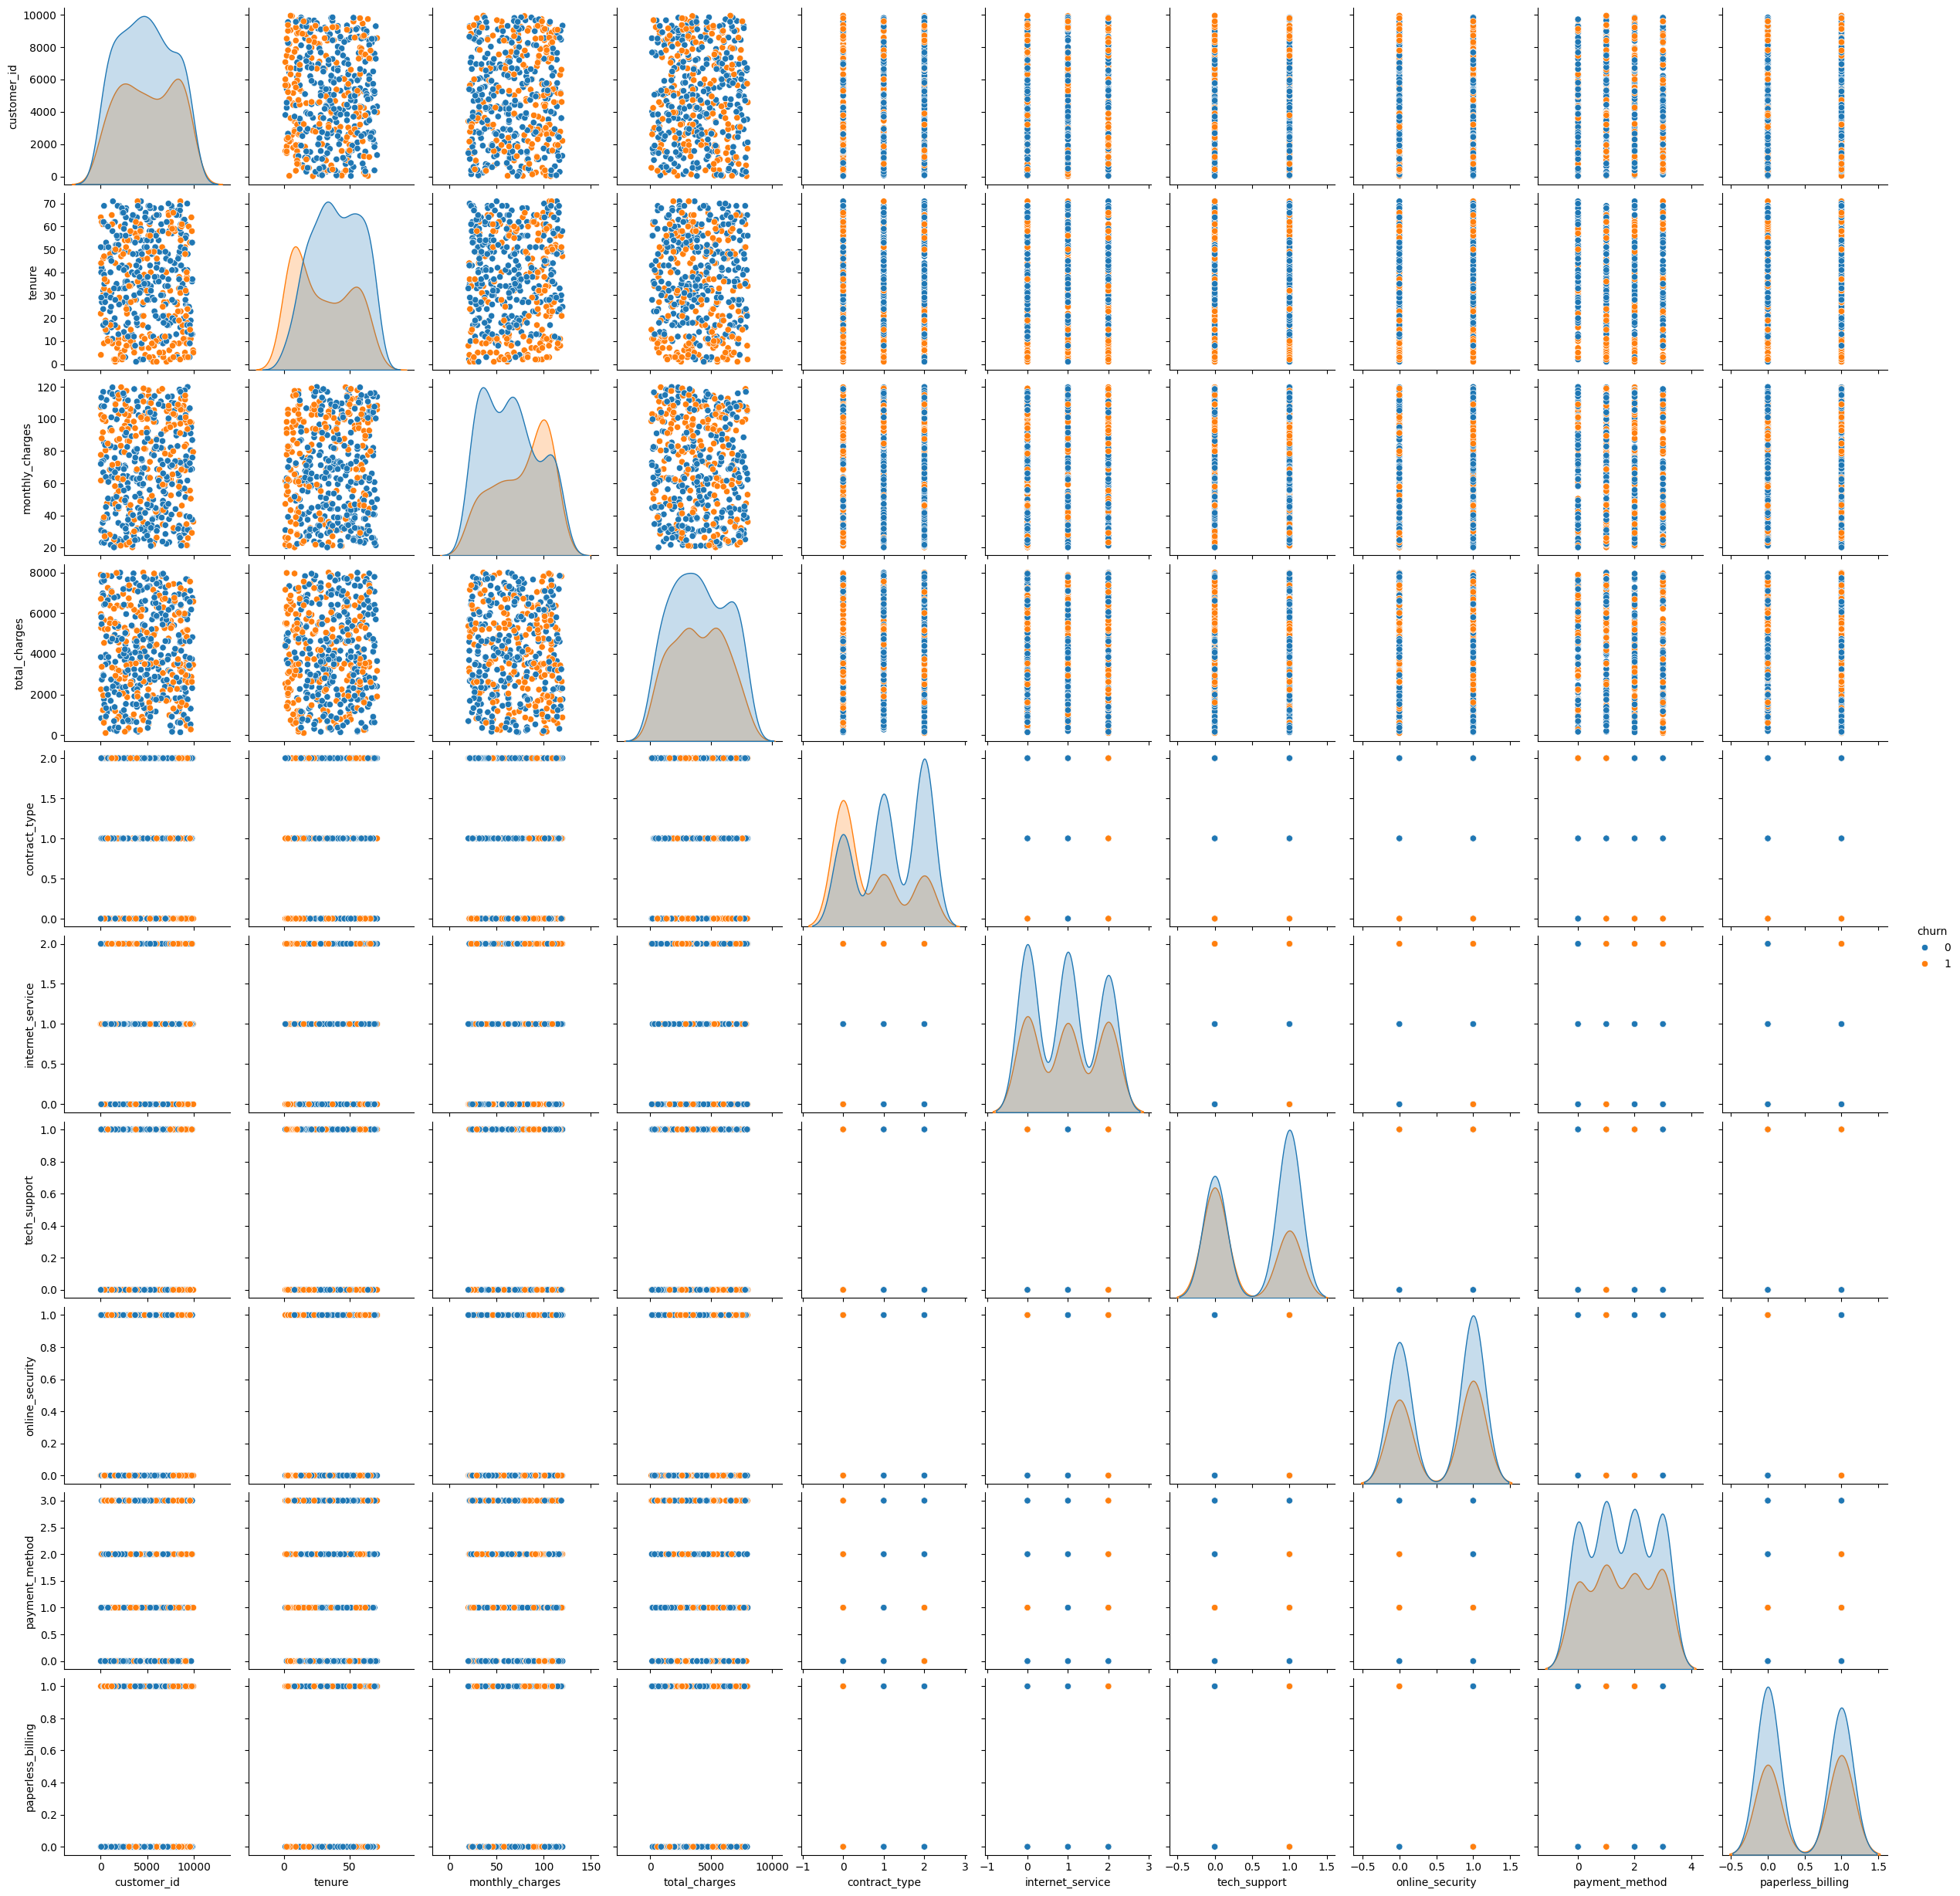

In [ ]:
sns.pairplot(df.sample(500), hue='churn')
plt.show()

Explaination: It shows relationship between multiple features simultaneously, helping identify patterns and separabilty between churn classes.

Feature importance

In [ ]:
corr = df.corr()['churn'].sort_values(ascending=False)
print(corr)

churn                1.000000
monthly_charges      0.249709
paperless_billing    0.019640
payment_method       0.009252
online_security     -0.000851
customer_id         -0.002349
total_charges       -0.003669
internet_service    -0.008560
tenure              -0.182206
tech_support        -0.199956
contract_type       -0.233490
Name: churn, dtype: float64


Explaination: This shows which features are most positively or negatively associated with churn. Higher positive correlation means the feature increases the likelihood of churn and higher negative correlation means it decreases it.

# Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Explaination: We split the data into training (80%) and testing (20%) sets to train the model on one portion and evaluate its performance on unseen data.

# Train SVM model

In [ ]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

SVC()

Explaination: we created an svm model with an rbf kernel (Radial basis function) and trained it on the training data to learn patterns for predicting churn.

# Prediction

In [ ]:
y_pred = model.predict(X_test)

Explaination: We used the trained SVM model to predict churn on the test set and generate the predicted output.

# Model Evaluation

In [ ]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', accuracy)

Accuracy:  0.7155


Explaination: The model predicts churn about 71.55% of the time (inshort, about 72 out of 100 times, the model predicted churn correctly.) on the test data, indicating its overall accuracy.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

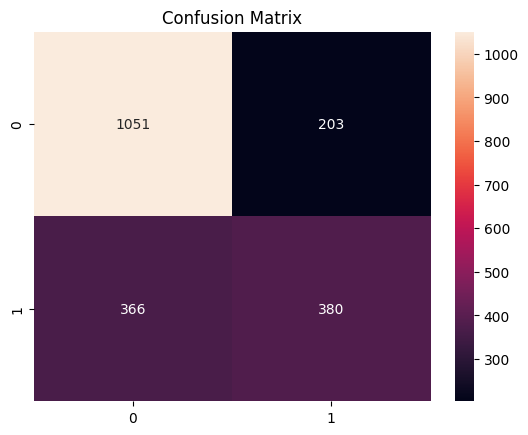

In [ ]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

Explaination: This matrix shows the model predicts non-churn customers more accurately than churn.



1.   True Negative = 1051 (customers who didnt churn and were correctly predicted  not churn.)
2.   False positive = 203 (Customers who did not churn but were incorrectly predicted as churn.)
3.   False Negative = 366 (Customers who churned but were incorrectly predicted as not churn.)
4.   True positive = 380 (Customers who churned and were correctly predicted as churn.)

True negative + True positive / total customer = accuracy





In [ ]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.84      0.79      1254
           1       0.65      0.51      0.57       746

    accuracy                           0.72      2000
   macro avg       0.70      0.67      0.68      2000
weighted avg       0.71      0.72      0.71      2000



Explaination: The classification model achieved 72% accuracy on the test set. It predicts class 0 (non-churn) more reliably than class 1 (churn), as shown by higher precision (0.74 vs 0.65) and recall (0.84 vs 0.51).

The F1-score reflects the balance between precision and recall, being 0.79 for class 0 and 0.57 for class 1.